# Real Estate Price Prediction: Model Exploration

## Objective
This notebook explores predictive modeling for the Las Vegas real estate market using the provided `data_master.csv`. 
Based on prior EDA and diagnostic insights, we will implement a robust modeling pipeline that addresses high skewness, multicollinearity, and outlier noise.

### Key Constraints & Decisions:
1. **Target Transformation**: The target `price` is extremely right-skewed (skew ≈ 10.3). We will use `log1p` transformation.
2. **Feature Engineering**: Creating ratios (`beds_per_bath`, `bath_per_sqft`) to capture relative space value.
3. **Validation Strategy**: Using a time-aware split based on `snapshot_date` to prevent data leakage from the future.
4. **Robustness**: Evaluating models using Median Absolute Error (MedAE) and MAE to minimize the impact of extreme luxury outliers.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_log_error
from sklearn.ensemble import GradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Initial Preparation

We drop `listingstatus` immediately as it is a constant (`FOR_SALE`) and provides no signal for prediction.

In [2]:
df = pd.read_csv('../data/raw/data_master.csv')
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

# Drop zero-variance columns
df = df.drop(columns=['listingstatus'])

print(f"Initial records: {len(df)}")
df.head()

Initial records: 1096


,price,bedrooms,bathrooms,livingarea,propertytype,vegas_district,latitude,longitude,snapshot_date
0,7100000.0,5,8.0,10153.0,SINGLE_FAMILY,Enterprise,35.979317,-115.192860,2026-02-20
1,534900.0,3,3.0,2122.0,SINGLE_FAMILY,Centennial,36.302166,-115.323170,2026-02-14
2,459900.0,3,3.0,1547.0,SINGLE_FAMILY,Mountains Edge,35.997093,-115.255905,2026-02-23
3,320000.0,3,3.0,1202.0,SINGLE_FAMILY,North Las Vegas,36.238663,-115.065834,2026-02-09
4,675000.0,5,3.0,3037.0,SINGLE_FAMILY,Centennial,36.290390,-115.324040,2026-02-20


In [3]:
df['price'].describe()

count    1.096000e+03
mean     8.421507e+05
std      2.010891e+06
min      2.000000e+03
25%      3.800000e+05
50%      4.950000e+05
75%      7.000000e+05
max      3.000000e+07
Name: price, dtype: float64

## 2. Outlier Management

**Critical Thinking:** 
With a max price of $30M against a median of $495k, the tail is enormous. 
We will calculate `price_per_sqft` (ppsf) as a diagnostic. 
Extreme ppsf values often indicate data entry errors or extremely unique assets that can degrade generalized model performance.

In [4]:
df['ppsf'] = df['price'] / df['livingarea']

# Diagnostic filter: removing extreme outliers defined by insights (ppsf < 80 or ppsf > 1000)
clean_mask = (df['ppsf'] >= 80) & (df['ppsf'] <= 1000)
outliers_removed = len(df) - clean_mask.sum()
df_clean = df[clean_mask].copy()

print(f"Removed {outliers_removed} extreme ppsf outliers.")
print(f"New range: {df_clean['price'].min():,.0f} to {df_clean['price'].max():,.0f}")

Removed 12 extreme ppsf outliers.
New range: 99,990 to 11,995,000


## 3. Feature Engineering

We introduce non-linear relationships and interactions manually:
- `log_livingarea`: Area is typically diminishing in marginal utility.
- `beds_per_bath`: Measures the efficiency/type of property layout.
- `bath_per_sqft`: Measures density of plumbing/high-cost construction area.

In [5]:
def engineer_features(data):
    d = data.copy()
    d['log_livingarea'] = np.log1p(d['livingarea'])
    d['beds_per_bath'] = d['bedrooms'] / (d['bathrooms'] + 0.1)
    d['bath_per_sqft'] = d['bathrooms'] / (d['livingarea'] + 0.1)
    return d

df_eng = engineer_features(df_clean)

## 4. Time-Aware Validation

**Critical Thinking:** 
Because our snapshots are taken daily, there is high temporal autocorrelation. 
A random split would 'leak' future information into the past. We will sort by date and split at the 80% mark.

In [7]:
df_eng = df_eng.sort_values('snapshot_date')
split_idx = int(len(df_eng) * 0.8)

train_df = df_eng.iloc[:split_idx]
test_df = df_eng.iloc[split_idx:]

print(f"Training Date Range: {train_df['snapshot_date'].min().date()} to {train_df['snapshot_date'].max().date()}")
print(f"Testing Date Range: {test_df['snapshot_date'].min().date()} to {test_df['snapshot_date'].max().date()}")

Training Date Range: 2026-02-07 to 2026-02-22
Testing Date Range: 2026-02-22 to 2026-02-23


## 5. Preprocessing Pipeline

We apply:
- **One-Hot Encoding** for `propertytype` and `vegas_district`.
- **Standard Scaling** for numerical inputs (essential for some models).
- **Log Transformation** on the target `price`.

In [8]:
features = [
    'bedrooms', 'bathrooms', 'livingarea', 'latitude', 'longitude', 
    'log_livingarea', 'beds_per_bath', 'bath_per_sqft', 
    'propertytype', 'vegas_district'
]
target = 'price'

X_train = train_df[features]
y_train = np.log1p(train_df[target])
X_test = test_df[features]
y_test = np.log1p(test_df[target])

numeric_features = ['bedrooms', 'bathrooms', 'livingarea', 'latitude', 'longitude', 'log_livingarea', 'beds_per_bath', 'bath_per_sqft']
categorical_features = ['propertytype', 'vegas_district']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

## 6. Model Training: GradientBoostingRegressor Baseline

GradientBoostingRegressor is chosen for its ability to handle non-linear interactions and potential multicollinearity (like living area vs. bathrooms) better than simple linear models.

In [9]:

model_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

model_base.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 7. Evaluation & Robust Metrics

We invert the log-prediction using `expm1` to calculate real-world dollar errors.

Mean Absolute Error (MAE): $115,852.84
Median Absolute Error (MedAE): $48,069.69


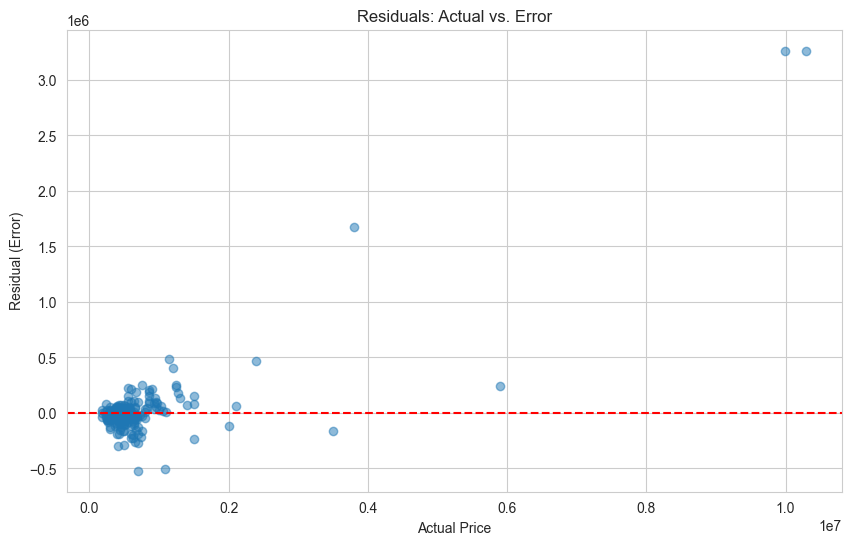

In [10]:
y_pred_log = model_base.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
med_ae = median_absolute_error(y_true, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Median Absolute Error (MedAE): ${med_ae:,.2f}")

# Residual Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_true - y_pred, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Residual (Error)')
plt.title('Residuals: Actual vs. Error')
plt.show()

## 8. Feature Importance

Analyzing which features drove the predictions the most.

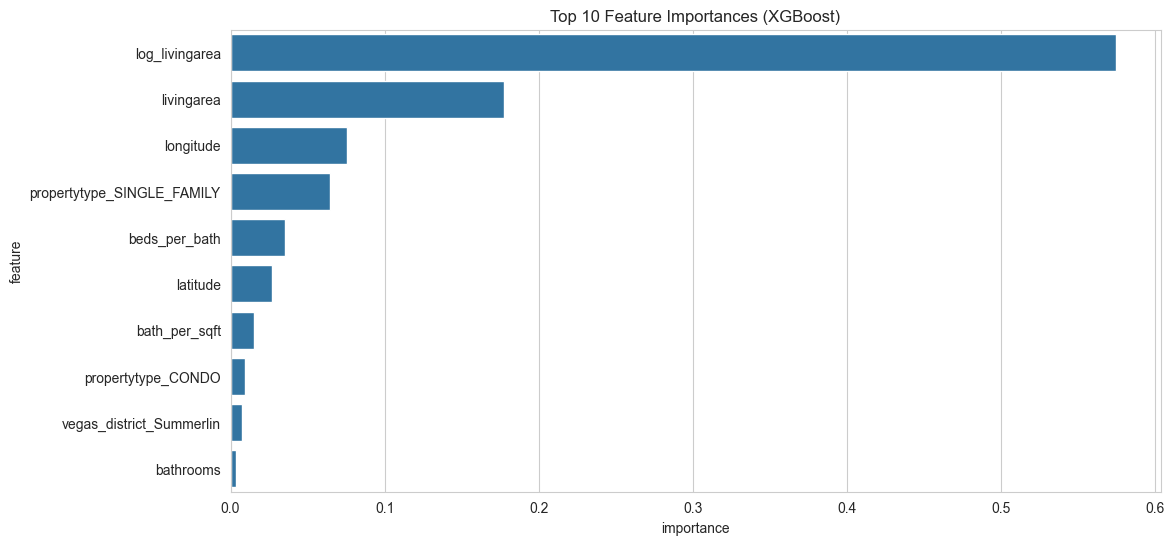

In [11]:
# Extract feature names from pipeline
ohe_cols = model_base.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(ohe_cols)

importances = model_base.named_steps['regressor'].feature_importances_
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

sns.barplot(data=feat_df.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.show()